## Załadujmy dane ze zbioru titanic
Zbiór Titanic został udostępniony na stronie [openml.org](https://www.openml.org/search?type=data&sort=runs&id=40945&status=active) w dwóch formatach: [arff (Attribute-Relation File Format)](https://www.cs.waikato.ac.nz/~ml/weka/arff.html) oraz [parquet](https://parquet.apache.org/)

Wczytanie pliku `parquet` wymaga zainstalowanej paczki [`pyarrow`](https://pypi.org/project/pyarrow/) lub [`fastparquet`](https://pypi.org/project/fastparquet/). Wczytanie  przy użyciu `pandas.read_parquet(filename)`.

Wczytanie pliku `arff` wymaga paczki np. [`liac-arff`](https://pypi.org/project/liac-arff/). Po wczytaniu pliku można go przekazać do konstruktora podstawowej struktury danych reprezentującej tabelę w bibliotece pandas tj. [`pandas.DataFrame`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.html).

### ARFF

In [1]:
import arff
import pandas as pd


def load_arff_to_dataframe(path):
    # Load the ARFF file
    with open(path, 'r') as f:
        arff_data = arff.load(f)
    
    # Extract data and attribute names
    data = arff_data['data']
    column_names = [attr[0] for attr in arff_data['attributes']]
    
    # Create a DataFrame
    df = pd.DataFrame(data, columns=column_names)
    
    return df

# Example usage
path_to_arff = '../titanic/titanic.arff'
df_arff = load_arff_to_dataframe(path_to_arff)
df_arff

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1.0,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0.0,0.0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1.0,1,"Allison, Master. Hudson Trevor",male,0.9167,1.0,2.0,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1.0,0,"Allison, Miss. Helen Loraine",female,2.0000,1.0,2.0,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1.0,0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1.0,2.0,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1.0,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1.0,2.0,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,3.0,0,"Zabour, Miss. Hileni",female,14.5000,1.0,0.0,2665,14.4542,NaN,C,NaN,328.0,NaN
1305,3.0,0,"Zabour, Miss. Thamine",female,NaN,1.0,0.0,2665,14.4542,NaN,C,NaN,NaN,NaN
1306,3.0,0,"Zakarian, Mr. Mapriededer",male,26.5000,0.0,0.0,2656,7.2250,NaN,C,NaN,304.0,NaN
1307,3.0,0,"Zakarian, Mr. Ortin",male,27.0000,0.0,0.0,2670,7.2250,NaN,C,NaN,NaN,NaN


In [10]:
df_arff

,pclass,...,home.dest
0,1.0,...,"St Louis, MO"
1,1.0,...,"Montreal, PQ / Chesterville, ON"
2,1.0,...,"Montreal, PQ / Chesterville, ON"
3,1.0,...,"Montreal, PQ / Chesterville, ON"
4,1.0,...,"Montreal, PQ / Chesterville, ON"
...,...,...,...
1304,3.0,...,NaN
1305,3.0,...,NaN
1306,3.0,...,NaN
1307,3.0,...,NaN


In [17]:
pd.set_option('display.max_columns', 30)

In [9]:
pd.set_option('display.max_rows', 10)

### parquet

In [11]:
df_parquet = pd.read_parquet('../titanic/dataset_40945.pq')
df_parquet

,pclass,...,home.dest
0,1,...,"St Louis, MO"
1,1,...,"Montreal, PQ / Chesterville, ON"
2,1,...,"Montreal, PQ / Chesterville, ON"
3,1,...,"Montreal, PQ / Chesterville, ON"
4,1,...,"Montreal, PQ / Chesterville, ON"
...,...,...,...
1304,3,...,NaN
1305,3,...,NaN
1306,3,...,NaN
1307,3,...,NaN


### Dalej popracujmy z `df = df_parquet` i obejrzyjmy szczegóły tej tabeli

In [45]:
df = df_parquet

#### Wyświetlenie pierwszych wierszy danych
print(df.head(n=10))

   pclass survived                                             name     sex  \
0       1        1                    Allen, Miss. Elisabeth Walton  female   
1       1        1                   Allison, Master. Hudson Trevor    male   
2       1        0                     Allison, Miss. Helen Loraine  female   
3       1        0             Allison, Mr. Hudson Joshua Creighton    male   
4       1        0  Allison, Mrs. Hudson J C (Bessie Waldo Daniels)  female   
5       1        1                              Anderson, Mr. Harry    male   
6       1        1                Andrews, Miss. Kornelia Theodosia  female   
7       1        0                           Andrews, Mr. Thomas Jr    male   
8       1        1    Appleton, Mrs. Edward Dale (Charlotte Lamson)  female   
9       1        0                          Artagaveytia, Mr. Ramon    male   

       age  sibsp  parch    ticket      fare    cabin embarked boat   body  \
0  29.0000      0      0     24160  211.3375       B

In [20]:
#### Podsumowanie informacji o danych
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   pclass     1309 non-null   uint8   
 1   survived   1309 non-null   category
 2   name       1309 non-null   str     
 3   sex        1309 non-null   category
 4   age        1046 non-null   float64 
 5   sibsp      1309 non-null   uint8   
 6   parch      1309 non-null   uint8   
 7   ticket     1309 non-null   str     
 8   fare       1308 non-null   float64 
 9   cabin      295 non-null    str     
 10  embarked   1307 non-null   category
 11  boat       486 non-null    str     
 12  body       121 non-null    float64 
 13  home.dest  745 non-null    str     
dtypes: category(3), float64(3), str(5), uint8(3)
memory usage: 149.2 KB
None


In [21]:
#### Statystyki opisowe dla danych numerycznych
print(df.describe())

            pclass          age        sibsp        parch         fare  \
count  1309.000000  1046.000000  1309.000000  1309.000000  1308.000000   
mean      2.294882    29.881135     0.498854     0.385027    33.295479   
std       0.837836    14.413500     1.041658     0.865560    51.758668   
min       1.000000     0.166700     0.000000     0.000000     0.000000   
25%       2.000000    21.000000     0.000000     0.000000     7.895800   
50%       3.000000    28.000000     0.000000     0.000000    14.454200   
75%       3.000000    39.000000     1.000000     0.000000    31.275000   
max       3.000000    80.000000     8.000000     9.000000   512.329200   

             body  
count  121.000000  
mean   160.809917  
std     97.696922  
min      1.000000  
25%     72.000000  
50%    155.000000  
75%    256.000000  
max    328.000000  


In [23]:
df['boat'].value_counts(dropna=False)

boat
NaN        823
13          39
C           38
15          37
14          33
          ... 
13 15        2
5 9          1
8 10         1
13 15 B      1
15 16        1
Name: count, Length: 28, dtype: int64

In [24]:
from collections import Counter
Counter(df['survived'])

Counter({'0': 809, '1': 500})

### można dopasować styl display:

In [25]:
pd.set_option?

Signature: pd.set_option(*args) -> 'None'
Docstring:
Set the value of the specified option or options.

This method allows fine-grained control over the behavior and display settings
of pandas. Options affect various functionalities such as output formatting,
display limits, and operational behavior. Settings can be modified at runtime
without requiring changes to global configurations or environment variables.

Parameters
----------
*args : str | object | dict
    Arguments provided in pairs, which will be interpreted as (pattern, value),
    or as a single dictionary containing multiple option-value pairs.
    pattern: str
    Regexp which should match a single option
    value: object
    New value of option

    .. warning::

        Partial pattern matches are supported for convenience, but unless you
        use the full option name (e.g. x.y.z.option_name), your code may break in
        future versions if new options with similar names are introduced.

Returns
-------
None
    

In [19]:
df.head()

,pclass,...,home.dest
0,1,...,"St Louis, MO"
1,1,...,"Montreal, PQ / Chesterville, ON"
2,1,...,"Montreal, PQ / Chesterville, ON"
3,1,...,"Montreal, PQ / Chesterville, ON"
4,1,...,"Montreal, PQ / Chesterville, ON"


In [27]:
#### Sprawdzenie brakujących wartości
print(df.isna().sum())


pclass          0
survived        0
name            0
sex             0
age           263
             ... 
cabin        1014
embarked        2
boat          823
body         1188
home.dest     564
Length: 14, dtype: int64


In [28]:
#### Wyświetlenie ile jest unikalnych wartości dla kolumn
df.nunique()

pclass          3
survived        2
name         1307
sex             2
age            98
             ... 
cabin         186
embarked        3
boat           27
body          121
home.dest     369
Length: 14, dtype: int64

In [29]:
#### Wyświetlenie unikalnych wartości dla kolumny
df['embarked'].unique()

['S', 'C', NaN, 'Q']
Categories (3, str): ['C' < 'Q' < 'S']

## Czyszczenie danych 

In [31]:
#### Identyfikacja i usunięcie duplikatów
df = df.drop_duplicates(subset=['name'])

In [32]:
df.shape

(1307, 14)

In [33]:
#### Obsługa brakujących wartości
df_without_empty_fare = df.dropna(subset='fare')
df_without_empty_fare

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,3,0,"Zabour, Miss. Hileni",female,14.5000,1,0,2665,14.4542,NaN,C,NaN,328.0,NaN
1305,3,0,"Zabour, Miss. Thamine",female,NaN,1,0,2665,14.4542,NaN,C,NaN,NaN,NaN
1306,3,0,"Zakarian, Mr. Mapriededer",male,26.5000,0,0,2656,7.2250,NaN,C,NaN,304.0,NaN
1307,3,0,"Zakarian, Mr. Ortin",male,27.0000,0,0,2670,7.2250,NaN,C,NaN,NaN,NaN


In [34]:
#### Przykład skalowania - MinMaxScaler
from sklearn.preprocessing import MinMaxScaler
data = [[-1, 2], [-0.5, 6], [0, 10], [1, 18]]
scaler = MinMaxScaler()
print(scaler.fit(data))

MinMaxScaler()


In [36]:

print(scaler.data_min_)

[-1.  2.]


In [37]:

print(scaler.transform(data))

[[0.   0.  ]
 [0.25 0.25]
 [0.5  0.5 ]
 [1.   1.  ]]


In [38]:
print(scaler.transform([[2, 2]]))

[[1.5 0. ]]


In [46]:
### Korekta typów danych
df = df.astype({'pclass': 'int32'})#.dtypes

In [47]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   pclass     1309 non-null   int32   
 1   survived   1309 non-null   category
 2   name       1309 non-null   str     
 3   sex        1309 non-null   category
 4   age        1046 non-null   float64 
 5   sibsp      1309 non-null   uint8   
 6   parch      1309 non-null   uint8   
 7   ticket     1309 non-null   str     
 8   fare       1308 non-null   float64 
 9   cabin      295 non-null    str     
 10  embarked   1307 non-null   category
 11  boat       486 non-null    str     
 12  body       121 non-null    float64 
 13  home.dest  745 non-null    str     
dtypes: category(3), float64(3), int32(1), str(5), uint8(2)
memory usage: 153.1 KB


In [48]:
df

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,3,0,"Zabour, Miss. Hileni",female,14.5000,1,0,2665,14.4542,NaN,C,NaN,328.0,NaN
1305,3,0,"Zabour, Miss. Thamine",female,NaN,1,0,2665,14.4542,NaN,C,NaN,NaN,NaN
1306,3,0,"Zakarian, Mr. Mapriededer",male,26.5000,0,0,2656,7.2250,NaN,C,NaN,304.0,NaN
1307,3,0,"Zakarian, Mr. Ortin",male,27.0000,0,0,2670,7.2250,NaN,C,NaN,NaN,NaN


## Graficzna wizualizacja danych
[User guide](https://pandas.pydata.org/pandas-docs/stable/user_guide/visualization.html)
### Demonstracja prostych wizualizacji z użyciem biblioteki [`matplotlib`](https://pypi.org/project/matplotlib/)

In [35]:
from matplotlib import pyplot as plt

<Axes: xlabel='pclass,survived'>

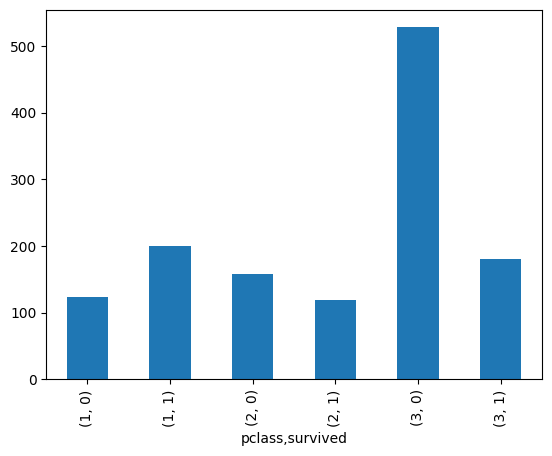

In [49]:
df.groupby(['pclass', 'survived'])['name'].count().plot.bar()